<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/chatbot_phapluat_dansu_4models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚖️ Chatbot Tư vấn Pháp luật Dân sự (BLDS 2015) — RAG + Fine-tuning

### Đề tài: So sánh 4 mô hình & Đánh giá định lượng — Luận văn Thạc sĩ Trí tuệ Nhân tạo

---

**Mục tiêu:** Xây dựng và **đánh giá định lượng** một chatbot hỏi–đáp pháp luật dân sự, so sánh **4 cấu hình mô hình**:

| Ký hiệu | Mô hình | Mô tả |
|:---:|---|---|
| **A** | **Qwen (Baseline)** | LLM gốc, không truy xuất, không fine-tune |
| **B** | **RAG + Qwen** | Truy xuất ngữ nghĩa (dense) → đưa điều luật vào ngữ cảnh |
| **C** | **Advanced RAG + Qwen** | RAG nâng cao: Hybrid (dense + BM25) + Query Expansion + Reranking |
| **D** | **Fine-tuning + Advanced RAG** | Mô hình LoRA fine-tune trên Q&A pháp luật + Advanced RAG |

**Bộ tiêu chí đánh giá (đáp ứng yêu cầu chấm):**
1. **Truy xuất đúng tài liệu:** `Recall@k`, `Precision@k`, `F1@k`, `MRR`, `nDCG@k`, `MAP`.
2. **Trả lời đúng:** `F1-score`, `Precision`, `Recall` (token-level), `ROUGE-L`, `Semantic Similarity`.
3. **Độ trễ (Latency):** thời gian phản hồi end-to-end (p50/p95), throughput.
4. **So sánh 4 mô hình:** bảng tổng hợp + biểu đồ + kiểm định ý nghĩa thống kê.
5. **Xử lý 3 kịch bản hội thoại:** câu hỏi trong/ngoài/kết hợp phạm vi pháp luật.

---

### 🗺️ Cấu trúc notebook

- **Phần 0** — Cài đặt & cấu hình
- **Phần 1** — Nạp & xử lý corpus BLDS 2015
- **Phần 2** — Xây dựng 4 mô hình (retriever + LLM)
- **Phần 3** — Bộ định tuyến 3 kịch bản hội thoại
- **Phần 4** — Tạo tập kiểm thử (test set)
- **Phần 5** — ⭐ Đánh giá & so sánh 4 mô hình (định lượng)
- **Phần 6** — ⭐ Bảng tổng hợp + biểu đồ + kiểm định thống kê
- **Phần 7** — Kiểm thử 3 kịch bản hội thoại
- **Phần 8** — 🚀 Demo Gradio (chatbot hoàn chỉnh)
- **Phần 9** — Kết luận

> **Lưu ý chế độ chạy:** Notebook có biến `FAST_DEMO`. Đặt `FAST_DEMO=True` để chạy nhanh bằng mô hình nhẹ (kiểm tra luồng). Đặt `FAST_DEMO=False` để chạy mô hình thật `Qwen2.5-3B-Instruct` cho số liệu luận văn.


# PHẦN 0 — Cài đặt & Cấu hình

Chạy ô dưới để cài thư viện. **Sau khi cài xong, vào menu `Runtime → Restart session`** rồi chạy tiếp từ Phần 1 (bỏ qua ô cài đặt).

In [1]:
# === 0.1. Cài đặt thư viện (chạy 1 lần, sau đó Restart session) ===
!pip install -q "numpy<2.0.0" "scipy<1.13.0"
!pip install -q sentence-transformers transformers accelerate
!pip install -q rank-bm25 chromadb
!pip install -q rouge-score gradio
# Cho fine-tuning (chỉ cần khi FAST_DEMO=False):
!pip install -q peft bitsandbytes trl datasets
print("\n✅ ĐÃ CÀI XONG — Hãy Runtime → Restart session trước khi chạy tiếp.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 14.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
cuml-cu12 26.2.0 requires scipy>=1.13.0, but you have scipy 1.12.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires scipy>=1.13, but y

In [1]:
# === 0.2. Cấu hình toàn cục ===
import os, json, time, random, warnings, math, re, unicodedata
import numpy as np
warnings.filterwarnings("ignore")

# -------- CHẾ ĐỘ CHẠY --------
# True  = chạy nhanh để KIỂM TRA LUỒNG (mô hình nhẹ, không cần GPU mạnh)
# False = chạy THẬT cho số liệu luận văn (Qwen2.5-3B-Instruct, cần GPU T4+)
FAST_DEMO = True

# -------- ĐƯỜNG DẪN --------
# Nếu chạy trên Colab có Drive, đổi CORPUS_PATH trỏ tới file của bạn.
# Mặc định: tải corpus mẫu đi kèm hoặc dùng file bạn upload lên /content/.
CORPUS_PATH = "blds_2015_parsed.json"   # đặt file này cùng thư mục notebook
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# -------- MÔ HÌNH --------
if FAST_DEMO:
    LLM_NAME = "Qwen/Qwen2.5-0.5B-Instruct"   # nhẹ, chạy nhanh để test luồng
else:
    LLM_NAME = "Qwen/Qwen2.5-3B-Instruct"     # mô hình thật cho luận văn
EMBED_NAME = "intfloat/multilingual-e5-base"  # base nhẹ hơn large; đổi -large nếu GPU khỏe
RERANKER_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

# -------- THAM SỐ --------
SEED = 42
TOP_K = 5            # số điều luật truy xuất
N_TEST = 40         # số câu trong test set (>= 30 theo yêu cầu)
random.seed(SEED); np.random.seed(SEED)

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Chế độ: {'FAST_DEMO (test luồng)' if FAST_DEMO else 'THẬT (luận văn)'}")
print(f"LLM: {LLM_NAME}")
print(f"Embedding: {EMBED_NAME}")
print(f"Thiết bị: {DEVICE}")

Chế độ: FAST_DEMO (test luồng)
LLM: Qwen/Qwen2.5-0.5B-Instruct
Embedding: intfloat/multilingual-e5-base
Thiết bị: cuda


# PHẦN 1 — Nạp & Xử lý Corpus BLDS 2015

Corpus là Bộ luật Dân sự 2015 đã parse thành **689 điều**, mỗi điều có: số điều, tiêu đề, nội dung, chương, phần.

In [2]:
# === 1.1. Nạp corpus ===
# Nếu chưa có file, tạo corpus mẫu nhỏ để notebook vẫn chạy được (minh hoạ luồng).
def load_corpus(path):
    if os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            data = json.load(f)
        print(f"✅ Đã nạp {len(data)} điều từ {path}")
        return data
    # Fallback: corpus mẫu (để chạy thử khi chưa upload file thật)
    print(f"⚠️  Không thấy {path} — dùng corpus MẪU 12 điều để minh hoạ luồng.")
    print("   → Hãy upload blds_2015_parsed.json để có kết quả thật.")
    sample = [
        (1,"Phạm vi điều chỉnh","Bộ luật này quy định địa vị pháp lý, chuẩn mực pháp lý về cách ứng xử của cá nhân, pháp nhân; quyền, nghĩa vụ về nhân thân và tài sản trong các quan hệ dân sự."),
        (116,"Giao dịch dân sự","Giao dịch dân sự là hợp đồng hoặc hành vi pháp lý đơn phương làm phát sinh, thay đổi hoặc chấm dứt quyền, nghĩa vụ dân sự."),
        (117,"Điều kiện có hiệu lực của giao dịch dân sự","Giao dịch dân sự có hiệu lực khi chủ thể có năng lực pháp luật, năng lực hành vi dân sự phù hợp; tham gia hoàn toàn tự nguyện; mục đích và nội dung không vi phạm điều cấm, không trái đạo đức xã hội."),
        (158,"Quyền sở hữu","Quyền sở hữu bao gồm quyền chiếm hữu, quyền sử dụng và quyền định đoạt tài sản của chủ sở hữu theo quy định của luật."),
        (175,"Ranh giới giữa các bất động sản","Ranh giới giữa các bất động sản liền kề được xác định theo thỏa thuận hoặc theo quyết định của cơ quan nhà nước có thẩm quyền."),
        (357,"Trách nhiệm do chậm thực hiện nghĩa vụ trả tiền","Trường hợp bên có nghĩa vụ chậm trả tiền thì bên đó phải trả lãi đối với số tiền chậm trả tương ứng với thời gian chậm trả."),
        (385,"Khái niệm hợp đồng","Hợp đồng là sự thỏa thuận giữa các bên về việc xác lập, thay đổi hoặc chấm dứt quyền, nghĩa vụ dân sự."),
        (463,"Hợp đồng vay tài sản","Hợp đồng vay tài sản là sự thỏa thuận giữa các bên, theo đó bên cho vay giao tài sản cho bên vay; khi đến hạn trả, bên vay phải hoàn trả tài sản cùng loại và lãi nếu có thỏa thuận."),
        (584,"Căn cứ phát sinh trách nhiệm bồi thường thiệt hại","Người nào có hành vi xâm phạm tính mạng, sức khỏe, danh dự, nhân phẩm, tài sản, quyền, lợi ích hợp pháp của người khác mà gây thiệt hại thì phải bồi thường."),
        (609,"Quyền thừa kế","Cá nhân có quyền lập di chúc để định đoạt tài sản của mình; để lại tài sản của mình cho người thừa kế theo pháp luật; hưởng di sản theo di chúc hoặc theo pháp luật."),
        (624,"Di chúc","Di chúc là sự thể hiện ý chí của cá nhân nhằm chuyển tài sản của mình cho người khác sau khi chết."),
        (651,"Người thừa kế theo pháp luật","Hàng thừa kế thứ nhất gồm: vợ, chồng, cha đẻ, mẹ đẻ, cha nuôi, mẹ nuôi, con đẻ, con nuôi của người chết."),
    ]
    return [{"dieu":f"Điều {n}","dieu_number":n,"title":t,"content":c,
             "chuong_title":"","phan_title":"",
             "source":"Bộ luật Dân sự 2015 (Luật số 91/2015/QH13)","effective_date":"01/01/2017"}
            for n,t,c in sample]

articles = load_corpus(CORPUS_PATH)
LAW_ID = "blds_2015"
LAW_NAME = "Bộ luật Dân sự 2015"
print(f"Tổng số điều: {len(articles)}")
print(f"Ví dụ: {articles[0]['dieu']} — {articles[0]['title']}")

✅ Đã nạp 689 điều từ blds_2015_parsed.json
Tổng số điều: 689
Ví dụ: Điều 1 — Phạm vi điều chỉnh


In [3]:
# === 1.2. Chuẩn bị văn bản cho truy xuất ===
# Mỗi điều -> 1 "document": ghép tiêu đề + nội dung để truy xuất tốt hơn.
def article_to_text(a):
    return f"{a['dieu']}. {a['title']}. {a['content']}".strip()

doc_texts = [article_to_text(a) for a in articles]
doc_ids   = [(LAW_ID, a["dieu_number"]) for a in articles]   # khóa định danh (law_id, số điều)
doc_meta  = [{"dieu": a["dieu"], "dieu_number": a["dieu_number"],
              "title": a["title"], "law_id": LAW_ID} for a in articles]
print(f"✅ Đã chuẩn bị {len(doc_texts)} documents cho truy xuất.")

✅ Đã chuẩn bị 689 documents cho truy xuất.


# PHẦN 2 — Xây dựng 4 Mô hình

Sự khác biệt cốt lõi giữa 4 cấu hình nằm ở **(1) cách truy xuất tài liệu** và **(2) mô hình sinh câu trả lời**:

| Cấu hình | Retriever | LLM |
|:---:|---|---|
| **A** Baseline | (không) | Qwen gốc |
| **B** RAG | Dense (e5) | Qwen gốc |
| **C** Advanced RAG | Dense + BM25 + Query Expansion + Reranking | Qwen gốc |
| **D** Fine-tune + Adv.RAG | Dense + BM25 + Query Expansion + Reranking | Qwen + LoRA |

Ta xây 2 retriever (`DenseRetriever` cho B, `AdvancedRetriever` cho C/D) và 1 LLM dùng chung (toggle LoRA).

## 2.1. Mô hình ngôn ngữ (LLM) — Qwen

In [4]:
# === 2.1. Nạp LLM (Qwen) ===
from transformers import AutoTokenizer, AutoModelForCausalLM

print(f"🔄 Đang nạp LLM: {LLM_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
model = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16 if DEVICE=="cuda" else torch.float32,
    device_map="auto" if DEVICE=="cuda" else None,
)
if DEVICE=="cpu":
    model = model.to(DEVICE)
model.eval()
print("✅ Đã nạp LLM.")

SYS_PROMPT = ("Bạn là trợ lý tư vấn pháp luật dân sự Việt Nam. "
              "Hãy trả lời bằng tiếng Việt, chính xác, ngắn gọn, "
              "và LUÔN trích dẫn số Điều cùng tên luật khi có căn cứ. "
              "Nếu ngữ cảnh không đủ thông tin, hãy nói rõ là chưa đủ căn cứ.")

def build_messages(question, contexts=None):
    """Tạo messages theo chat template của Qwen."""
    if contexts:
        ctx = "\n\n".join(f"[{c['dieu']}] {c['title']}: {c['text']}" for c in contexts)
        user = (f"Dưới đây là các điều luật liên quan:\n{ctx}\n\n"
                f"Dựa vào các điều luật trên, hãy trả lời câu hỏi: {question}")
    else:
        user = question
    return [{"role":"system","content":SYS_PROMPT},
            {"role":"user","content":user}]

@torch.no_grad()
def llm_generate(question, contexts=None, max_new_tokens=300, adapter=False):
    """Sinh câu trả lời. adapter=True dùng LoRA (cấu hình D) nếu đã gắn."""
    messages = build_messages(question, contexts)
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    # Bật/tắt adapter LoRA nếu có
    if hasattr(model, "disable_adapter") and not adapter:
        with model.disable_adapter():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
    else:
        out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                             do_sample=False, pad_token_id=tokenizer.eos_token_id)
    ans = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return ans.strip()

# Kiểm tra nhanh
print("Test LLM:", llm_generate("Quyền thừa kế là gì?", max_new_tokens=60)[:150])

🔄 Đang nạp LLM: Qwen/Qwen2.5-0.5B-Instruct ...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Đã nạp LLM.
Test LLM: Quyền thừa kế là quyền tự do của người thừa kế để quản lý tài sản của họ cho người khác sau khi họ qua đời hoặc khi họ không còn sống.


## 2.2. Embedding & Dense Retriever (dùng cho B, C, D)

In [5]:
# === 2.2. Embedding model + chỉ mục dense ===
from sentence_transformers import SentenceTransformer

print(f"🔄 Đang nạp embedding: {EMBED_NAME} ...")
embedder = SentenceTransformer(EMBED_NAME, device=DEVICE)

# e5 yêu cầu prefix: "passage: " cho tài liệu, "query: " cho câu hỏi
print("🔄 Đang mã hóa corpus (embedding)...")
doc_embeddings = embedder.encode(
    [f"passage: {t}" for t in doc_texts],
    batch_size=32, normalize_embeddings=True, show_progress_bar=True
)
doc_embeddings = np.asarray(doc_embeddings, dtype=np.float32)
print(f"✅ Đã mã hóa {doc_embeddings.shape[0]} điều, chiều vector = {doc_embeddings.shape[1]}")

def dense_search(query, top_k=TOP_K):
    """Trả về list (index, score) theo cosine similarity giảm dần."""
    q = embedder.encode([f"query: {query}"], normalize_embeddings=True)[0]
    scores = doc_embeddings @ q              # cosine vì đã normalize
    idx = np.argsort(-scores)[:top_k]
    return [(int(i), float(scores[i])) for i in idx]

🔄 Đang nạp embedding: intfloat/multilingual-e5-base ...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

🔄 Đang mã hóa corpus (embedding)...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

✅ Đã mã hóa 689 điều, chiều vector = 768


## 2.3. Advanced RAG: BM25 + Query Expansion + Reranking (dùng cho C, D)

- **BM25 (lexical):** bắt từ khóa chính xác mà embedding có thể bỏ sót.
- **Query Expansion:** mở rộng câu hỏi bằng từ điển thuật ngữ "đời thường → pháp lý".
- **Reranking:** cross-encoder chấm lại độ liên quan của ứng viên → xếp hạng tinh.

In [6]:
# === 2.3. BM25 + Query Expansion + Reranker ===
from rank_bm25 import BM25Okapi

def vi_tokenize(text):
    """Tách từ đơn giản cho tiếng Việt (lowercase + tách theo khoảng trắng/dấu)."""
    text = unicodedata.normalize("NFC", text.lower())
    text = re.sub(r"[^0-9a-zàáảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ\s]", " ", text)
    return text.split()

print("🔄 Xây chỉ mục BM25...")
bm25 = BM25Okapi([vi_tokenize(t) for t in doc_texts])

# Từ điển mở rộng truy vấn: đời thường -> thuật ngữ pháp lý
QUERY_EXPANSION = {
    "lấn chiếm": "lấn chiếm ranh giới bất động sản quyền sở hữu",
    "mượn tiền": "vay tài sản hợp đồng vay",
    "vay tiền": "vay tài sản hợp đồng vay lãi suất",
    "chia tài sản": "thừa kế di sản phân chia",
    "để lại tài sản": "thừa kế di chúc di sản",
    "đền bù": "bồi thường thiệt hại",
    "ký hợp đồng": "giao kết hợp đồng giao dịch dân sự",
    "hàng xóm": "bất động sản liền kề ranh giới",
    "con cái": "con đẻ con nuôi thừa kế",
}

def expand_query(query):
    q = query.lower()
    extra = [v for k,v in QUERY_EXPANSION.items() if k in q]
    return query + (" " + " ".join(extra) if extra else "")

def bm25_search(query, top_k=TOP_K):
    scores = bm25.get_scores(vi_tokenize(query))
    idx = np.argsort(-scores)[:top_k]
    return [(int(i), float(scores[i])) for i in idx]

# Reranker (cross-encoder)
from sentence_transformers import CrossEncoder
print(f"🔄 Nạp reranker: {RERANKER_NAME} ...")
try:
    reranker = CrossEncoder(RERANKER_NAME, device=DEVICE)
    HAS_RERANKER = True
except Exception as e:
    print("⚠️  Không nạp được reranker, sẽ bỏ qua bước rerank:", e)
    HAS_RERANKER = False

def rerank(query, cand_indices, top_k=TOP_K):
    if not HAS_RERANKER or not cand_indices:
        return cand_indices[:top_k]
    pairs = [[query, doc_texts[i]] for i in cand_indices]
    scores = reranker.predict(pairs)
    order = np.argsort(-scores)
    return [cand_indices[o] for o in order[:top_k]]

print("✅ Advanced RAG components sẵn sàng.")

🔄 Xây chỉ mục BM25...
🔄 Nạp reranker: cross-encoder/ms-marco-MiniLM-L-6-v2 ...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ Advanced RAG components sẵn sàng.


## 2.4. Định nghĩa Retriever cho từng cấu hình

Ta gói thành 1 hàm `retrieve(query, mode)` với `mode ∈ {basic, advanced}` để dùng nhất quán.

In [7]:
# === 2.4. Hàm truy xuất thống nhất ===
def _sigmoid(x): return 1.0/(1.0+math.exp(-x))

def retrieve(query, mode="advanced", top_k=TOP_K):
    """
    mode="basic"    -> chỉ Dense (cấu hình B).
    mode="advanced" -> Dense ∪ BM25 + Query Expansion + Rerank (cấu hình C, D).
    Trả về: (list điều luật [dict], confidence float).
    """
    if mode == "basic":
        hits = dense_search(query, top_k)
        cand = [i for i,_ in hits]
        raw_conf = hits[0][1] if hits else 0.0
        conf = float(raw_conf)  # cosine ∈ [0,1]
    else:
        eq = expand_query(query)
        dense_hits = dense_search(eq, top_k*2)
        bm25_hits  = bm25_search(eq, top_k*2)
        # hợp nhất ứng viên (union)
        cand = list(dict.fromkeys([i for i,_ in dense_hits] + [i for i,_ in bm25_hits]))
        cand = rerank(query, cand, top_k)
        # confidence từ reranker (nếu có) hoặc dense
        if HAS_RERANKER and cand:
            s = reranker.predict([[query, doc_texts[cand[0]]]])[0]
            conf = _sigmoid(float(s))
        else:
            conf = dense_hits[0][1] if dense_hits else 0.0
    docs = [{"index":i, "dieu":doc_meta[i]["dieu"], "dieu_number":doc_meta[i]["dieu_number"],
             "title":doc_meta[i]["title"], "text":doc_texts[i],
             "key":(LAW_ID, doc_meta[i]["dieu_number"])} for i in cand]
    return docs, conf

# Test
_d,_c = retrieve("Hàng thừa kế thứ nhất gồm những ai?", mode="advanced")
print(f"Test retrieve (advanced): conf={_c:.3f}")
for d in _d[:3]:
    print(f"   {d['dieu']}: {d['title']}")

Test retrieve (advanced): conf=0.999
   Điều 651: Người thừa kế theo pháp luật
   Điều 660: Phân chia di sản theo pháp luật
   Điều 606: Bồi thường thiệt hại do xâm phạm thi thể


# PHẦN 3 — Bộ Định tuyến 3 Kịch bản Hội thoại

Một chatbot pháp luật tốt phải biết **khi nào nên trả lời** và **khi nào nên từ chối**. Ta xây bộ định tuyến (router) phân loại câu hỏi thành 3 nhóm và quy định cách ứng xử:

| Kịch bản | Ví dụ | Cách ứng xử của chatbot |
|---|---|---|
| **🟢 Pháp luật** | *"Hàng thừa kế thứ nhất gồm ai?"* | Trả lời dựa trên RAG + trích Điều luật |
| **🟡 Ngoài phạm vi** | *"Hôm nay thời tiết thế nào?"* | Từ chối lịch sự, nêu rõ phạm vi, **KHÔNG bịa luật** |
| **🔵 Kết hợp** | *"Quyền nuôi con là gì, và gợi ý quán ăn ngon?"* | Trả lời phần luật, **tách bạch** & từ chối phần ngoài |

**Cơ chế phân loại** dùng 2 tín hiệu bổ trợ nhau:
1. **Từ khóa miền pháp luật dân sự** (rule-based, minh bạch, dễ giải thích).
2. **Độ tin cậy truy xuất** (retrieval confidence) — nếu retriever tự tin tìm được điều luật liên quan, đó là tín hiệu câu hỏi thuộc miền pháp luật.

In [8]:
# === 3.1. Bộ từ khóa miền pháp luật dân sự ===
LEGAL_KEYWORDS = [
    # Khái niệm chung
    "điều luật","luật","pháp luật","bộ luật","dân sự","quy định","khởi kiện","tranh chấp",
    "quyền","nghĩa vụ","trách nhiệm","vi phạm","hợp pháp","bất hợp pháp","thẩm quyền",
    # Tài sản & sở hữu
    "tài sản","sở hữu","chiếm hữu","định đoạt","bất động sản","động sản","đất đai",
    "lấn chiếm","ranh giới","lối đi","quyền sử dụng đất",
    # Hợp đồng & giao dịch
    "hợp đồng","giao dịch","thỏa thuận","giao kết","vay","mượn","tặng cho","mua bán",
    "thuê","đặt cọc","thế chấp","cầm cố","bảo lãnh","bảo đảm","lãi suất","phạt vi phạm",
    # Thừa kế
    "thừa kế","di chúc","di sản","người thừa kế","hàng thừa kế","để lại tài sản",
    # Bồi thường, nhân thân
    "bồi thường","thiệt hại","đền bù","danh dự","nhân phẩm","tính mạng","sức khỏe",
    # Chủ thể, hôn nhân-gia đình (giao thoa dân sự)
    "cá nhân","pháp nhân","năng lực hành vi","đại diện","ủy quyền","giám hộ",
    "hôn nhân","ly hôn","kết hôn","cấp dưỡng","con nuôi","nuôi con","vợ chồng",
    "thời hiệu","hiệu lực","vô hiệu",
]

def normalize_text(s):
    return unicodedata.normalize("NFC", str(s)).lower().strip()

print(f"✅ Bộ từ khóa: {len(LEGAL_KEYWORDS)} thuật ngữ pháp luật dân sự.")

# Từ khóa RÕ RÀNG ngoài phạm vi pháp luật dân sự (giúp router từ chối chính xác)
OUT_OF_SCOPE_HINTS = [
    "thời tiết","nhiệt độ","mưa","nắng","nấu","món ăn","công thức","ẩm thực","quán ăn",
    "quán cà phê","nhà hàng","bitcoin","tiền ảo","chứng khoán","cổ phiếu","tỷ giá",
    "bóng đá","thể thao","trận đấu","phim","ca nhạc","bài hát","du lịch","khách sạn",
    "vé máy bay","code","lập trình","python","javascript","game","trò chơi","mua sắm",
    "điện thoại","laptop","giảm cân","tập gym","yoga","đội tuyển","đá bóng",
    "ca sĩ","diễn viên","nghệ sĩ","tin tức","thời sự",
]
print(f"✅ Bộ từ khóa ngoài phạm vi: {len(OUT_OF_SCOPE_HINTS)} mục.")

✅ Bộ từ khóa: 71 thuật ngữ pháp luật dân sự.
✅ Bộ từ khóa ngoài phạm vi: 44 mục.


In [9]:
# === 3.2. Hàm phân loại câu hỏi ===
def split_clauses(text):
    """Tách câu hỏi thành các mệnh đề để phát hiện câu KẾT HỢP."""
    t = normalize_text(text)
    parts = re.split(r"[?.!;\n]|,?\s*(?:và|hoặc|đồng thời|tiện thể|ngoài ra|với lại)\s+", t)
    return [p.strip() for p in parts if len(p.strip()) > 3]

def is_legal_clause(clause):
    return any(kw in clause for kw in LEGAL_KEYWORDS)

def is_out_of_scope_clause(clause):
    return any(h in clause for h in OUT_OF_SCOPE_HINTS)

def classify_query(question, retr_conf=None, conf_threshold=0.62):
    """
    Phân loại câu hỏi -> ('legal' | 'out_of_scope' | 'mixed', meta).
    Ưu tiên (theo thứ tự):
      1. Mệnh đề có từ khóa luật + mệnh đề ngoài phạm vi -> 'mixed'.
      2. Có từ khóa luật -> 'legal'.
      3. Có từ khóa RÕ RÀNG ngoài phạm vi (và không có từ khóa luật) -> 'out_of_scope'.
      4. Không rõ ràng + retriever RẤT tự tin (conf cao) -> 'legal'; ngược lại 'out_of_scope'.
    """
    clauses = split_clauses(question)
    q_norm = normalize_text(question)

    legal_clauses    = [c for c in clauses if is_legal_clause(c)]
    nonlegal_clauses = [c for c in clauses if not is_legal_clause(c)]
    has_legal_kw     = bool(legal_clauses) or is_legal_clause(q_norm)
    has_oos_kw       = any(is_out_of_scope_clause(c) for c in clauses) or is_out_of_scope_clause(q_norm)

    # (1) KẾT HỢP: vừa có mệnh đề luật, vừa có mệnh đề ngoài phạm vi
    mixed_nonlegal = [c for c in nonlegal_clauses if is_out_of_scope_clause(c) or len(nonlegal_clauses)>0]
    if legal_clauses and nonlegal_clauses and (has_oos_kw or len(nonlegal_clauses)>=1):
        return "mixed", {"legal":legal_clauses, "nonlegal":nonlegal_clauses}

    # (2) Có từ khóa luật rõ ràng -> pháp luật
    if has_legal_kw and not has_oos_kw:
        return "legal", {"legal":clauses, "nonlegal":[]}

    # (3) Có từ khóa ngoài phạm vi rõ ràng (không kèm từ khóa luật) -> ngoài phạm vi
    if has_oos_kw and not has_legal_kw:
        return "out_of_scope", {"legal":[], "nonlegal":clauses}

    # (4) Không rõ ràng: chỉ tin retriever khi RẤT tự tin
    if has_legal_kw:
        return "legal", {"legal":clauses, "nonlegal":[]}
    if retr_conf is not None and retr_conf >= conf_threshold:
        return "legal", {"legal":clauses, "nonlegal":[]}
    return "out_of_scope", {"legal":[], "nonlegal":clauses}

print("✅ Hàm phân loại sẵn sàng (ưu tiên từ khóa, conf chỉ dùng khi rất tự tin).")

✅ Hàm phân loại sẵn sàng (ưu tiên từ khóa, conf chỉ dùng khi rất tự tin).


In [10]:
# === 3.3. Hàm trả lời theo kịch bản (tích hợp router + 4 cấu hình) ===
SCOPE_TEXT = f"{LAW_NAME} (Bộ luật Dân sự Việt Nam)"

REFUSAL_TEMPLATE = (
    f"Xin lỗi, tôi là trợ lý chuyên tư vấn về **{SCOPE_TEXT}**. "
    f"Câu hỏi của bạn nằm ngoài phạm vi này nên tôi không thể trả lời. "
    f"Bạn vui lòng đặt câu hỏi liên quan đến pháp luật dân sự "
    f"(thừa kế, hợp đồng, sở hữu tài sản, bồi thường thiệt hại, giao dịch dân sự...) "
    f"để tôi hỗ trợ tốt nhất nhé."
)

def answer_chatbot(question, config="D", conf_threshold=0.62, max_new_tokens=300):
    """
    Chatbot HOÀN CHỈNH có định tuyến 3 kịch bản.
    config: 'A'/'B'/'C'/'D' — chọn cấu hình mô hình.
            A=baseline(no RAG), B=basic RAG, C=advanced RAG, D=advanced RAG + LoRA.
    Trả về dict: {label, response, used_rag, confidence, cited}
    """
    q = (question or "").strip()
    if not q:
        return {"label":"empty","response":"Bạn vui lòng nhập câu hỏi.","used_rag":False,
                "confidence":0.0,"cited":[]}

    use_rag  = config in ("B","C","D")
    use_lora = (config == "D")
    mode = "basic" if config=="B" else "advanced"

    # Truy xuất trước (nếu cấu hình có RAG) để lấy confidence cho router
    docs, conf = ([], 0.0)
    if use_rag:
        docs, conf = retrieve(q, mode=mode)

    # Phân loại kịch bản
    label, meta = classify_query(q, retr_conf=conf if use_rag else None,
                                 conf_threshold=conf_threshold)

    # --- Kịch bản 2: ngoài phạm vi -> từ chối, KHÔNG bịa ---
    if label == "out_of_scope":
        return {"label":label,"response":REFUSAL_TEMPLATE,"used_rag":False,
                "confidence":float(conf),"cited":[]}

    # --- Kịch bản 1: pháp luật ---
    if label == "legal":
        ctx = docs[:4] if use_rag else None
        resp = llm_generate(q, contexts=ctx, max_new_tokens=max_new_tokens, adapter=use_lora)
        cited = [f"{d['dieu']} — {d['title']}" for d in docs[:4]] if use_rag else []
        if use_rag and conf < conf_threshold:
            resp += ("\n\n_(Lưu ý: độ liên quan của điều luật truy xuất khá thấp, "
                     "bạn nên kiểm chứng thêm hoặc đặt câu hỏi cụ thể hơn.)_")
        return {"label":label,"response":resp,"used_rag":use_rag,
                "confidence":float(conf),"cited":cited}

    # --- Kịch bản 3: kết hợp -> trả lời phần luật + tách bạch phần ngoài ---
    legal_q = " ".join(meta["legal"]) or q
    ctx = docs[:4] if use_rag else None
    legal_resp = llm_generate(legal_q, contexts=ctx, max_new_tokens=max_new_tokens, adapter=use_lora)
    cited = [f"{d['dieu']} — {d['title']}" for d in docs[:4]] if use_rag else []
    response = (
        "**📗 Phần thuộc pháp luật dân sự:**\n" + legal_resp +
        "\n\n**📕 Phần ngoài phạm vi:** Câu hỏi của bạn còn có nội dung không thuộc "
        f"pháp luật dân sự, tôi xin phép không trả lời phần đó vì chỉ hỗ trợ về {SCOPE_TEXT}."
    )
    return {"label":label,"response":response,"used_rag":use_rag,
            "confidence":float(conf),"cited":cited}

print("✅ Chatbot có định tuyến 3 kịch bản sẵn sàng (answer_chatbot).")

✅ Chatbot có định tuyến 3 kịch bản sẵn sàng (answer_chatbot).


# PHẦN 4 — Tạo Tập Kiểm thử (Test Set)

Để đánh giá khách quan, ta cần tập kiểm thử có **đáp án chuẩn (ground truth)** gồm:
- `question`: câu hỏi.
- `gold_article`: điều luật đúng `(law_id, số điều)` — dùng đánh giá **truy xuất**.
- `gold_answer`: đáp án mẫu — dùng đánh giá **chất lượng trả lời**.

> **Thực tế luận văn:** đáp án chuẩn nên do **chuyên gia/người duyệt** xác nhận. Ở đây ta sinh tự động từ chính nội dung điều luật (tóm tắt) để minh hoạ; bạn có thể thay bằng test set đã duyệt tay (`test_set_reviewed.json`).

In [11]:
# === 4.1. Sinh test set từ corpus (đáp án bám sát điều luật) ===
def make_question(title):
    t = title.strip().rstrip(".")
    tl = t.lower()
    if tl.startswith(("quyền","nghĩa vụ")):
        return f"Pháp luật quy định thế nào về {tl}?"
    if tl.startswith(("thời hiệu","thời hạn")):
        return f"{t} được quy định ra sao?"
    if tl.startswith(("hợp đồng","giao dịch")):
        return f"{t} là gì và được pháp luật quy định thế nào?"
    if tl.startswith(("điều kiện","nguyên tắc","căn cứ")):
        return f"{t} gồm những gì?"
    if "thừa kế" in tl or "di chúc" in tl or "di sản" in tl:
        return f"{t} được quy định như thế nào trong Bộ luật Dân sự?"
    return f"Pháp luật quy định thế nào về {tl}?"

def make_gold_answer(article):
    """Đáp án mẫu = tóm tắt nội dung điều (2-3 câu đầu)."""
    content = re.sub(r"\s+"," ", article["content"].replace("\n"," ")).strip()
    sentences = re.split(r"(?<=[.;])\s+", content)
    summary = " ".join(sentences[:3])[:400]
    return f"Theo {article['dieu']} {LAW_NAME}: {summary}"

# Chọn N_TEST điều ngẫu nhiên (ưu tiên điều có nội dung đủ dài)
candidates = [a for a in articles if len(a["content"]) > 80]
random.seed(SEED)
chosen = random.sample(candidates, min(N_TEST, len(candidates)))

test_set = []
for a in chosen:
    test_set.append({
        "question": make_question(a["title"]),
        "gold_article": (LAW_ID, a["dieu_number"]),
        "gold_answer": make_gold_answer(a),
        "dieu": a["dieu"],
        "title": a["title"],
    })

# Lưu lại
with open(f"{RESULTS_DIR}/test_set.json","w",encoding="utf-8") as f:
    json.dump([{**t,"gold_article":list(t["gold_article"])} for t in test_set],
              f, ensure_ascii=False, indent=2)

print(f"✅ Đã tạo test set: {len(test_set)} câu hỏi")
print(f"\nVí dụ:")
for t in test_set[:3]:
    print(f"  Q: {t['question']}")
    print(f"  Gold: {t['dieu']} | Đáp án: {t['gold_answer'][:80]}...\n")

✅ Đã tạo test set: 40 câu hỏi

Ví dụ:
  Q: Phân chia di sản theo pháp luật được quy định như thế nào trong Bộ luật Dân sự?
  Gold: Điều 660 | Đáp án: Theo Điều 660 Bộ luật Dân sự 2015: 1. Khi phân chia di sản, nếu có người thừa kế...

  Q: Điều kiện có hiệu lực của giao dịch dân sự gồm những gì?
  Gold: Điều 117 | Đáp án: Theo Điều 117 Bộ luật Dân sự 2015: 1. Giao dịch dân sự có hiệu lực khi có đủ các...

  Q: Pháp luật quy định thế nào về quyền có họ, tên?
  Gold: Điều 26 | Đáp án: Theo Điều 26 Bộ luật Dân sự 2015: 1. Cá nhân có quyền có họ, tên (bao gồm cả chữ...



# PHẦN 4B — (Tùy chọn) Fine-tuning LoRA cho Cấu hình D

Cấu hình **D** cần một mô hình đã fine-tune. Phần này huấn luyện **LoRA** (Low-Rank Adaptation) — phương pháp fine-tune hiệu quả, chỉ cập nhật ~0.1% tham số.

> ⏳ **Lưu ý:** Phần này cần GPU và mất thời gian. Khi `FAST_DEMO=True` sẽ huấn luyện rất ngắn (chỉ để minh hoạ luồng). Đặt `FAST_DEMO=False` + tăng `num_epochs` để có LoRA thật cho luận văn.
>
> **Có thể bỏ qua phần này** — khi đó cấu hình D sẽ tạm dùng model gốc (giống C) và notebook vẫn chạy đủ các phần đánh giá.

In [12]:
# === 4B.1. Sinh dữ liệu huấn luyện (Q&A từ điều luật KHÔNG nằm trong test set) ===
# Chống data leakage: loại các điều đã dùng làm test.
test_dieu_numbers = set(t["gold_article"][1] for t in test_set)
train_articles = [a for a in articles if a["dieu_number"] not in test_dieu_numbers]
print(f"Điều dùng cho train: {len(train_articles)} / {len(articles)} "
      f"(đã loại {len(test_dieu_numbers)} điều thuộc test → chống leakage)")

def make_training_pairs(arts, max_pairs=300):
    pairs = []
    for a in arts:
        if len(a["content"]) < 60: continue
        q = make_question(a["title"])
        content = re.sub(r"\s+"," ", a["content"].replace("\n"," ")).strip()
        ans = f"Theo {a['dieu']} {LAW_NAME}: {content[:500]}"
        pairs.append({"question":q, "answer":ans})
        if len(pairs) >= max_pairs: break
    return pairs

train_pairs = make_training_pairs(train_articles, max_pairs=50 if FAST_DEMO else 300)
print(f"✅ Đã sinh {len(train_pairs)} cặp Q&A để huấn luyện.")
print(f"Ví dụ: Q: {train_pairs[0]['question']}")
print(f"        A: {train_pairs[0]['answer'][:100]}...")

Điều dùng cho train: 649 / 689 (đã loại 40 điều thuộc test → chống leakage)
✅ Đã sinh 50 cặp Q&A để huấn luyện.
Ví dụ: Q: Pháp luật quy định thế nào về phạm vi điều chỉnh?
        A: Theo Điều 1 Bộ luật Dân sự 2015: Bộ luật này quy định địa vị pháp lý, chuẩn mực pháp lý về cách ứng ...


In [13]:
# === 4B.2. Huấn luyện LoRA ===
RUN_TRAINING = True   # đặt False để bỏ qua training

if RUN_TRAINING:
    try:
        from peft import LoraConfig, get_peft_model
        from datasets import Dataset

        def format_sample(ex):
            messages = build_messages(ex["question"], contexts=None)
            messages.append({"role":"assistant","content":ex["answer"]})
            text = tokenizer.apply_chat_template(messages, tokenize=False)
            return {"text": text}

        train_ds = Dataset.from_list(train_pairs).map(format_sample)

        def tokenize_fn(ex):
            out = tokenizer(ex["text"], truncation=True, max_length=512, padding="max_length")
            out["labels"] = out["input_ids"].copy()
            return out
        train_ds = train_ds.map(tokenize_fn, remove_columns=train_ds.column_names)

        lora_config = LoraConfig(
            r=8, lora_alpha=16, lora_dropout=0.05,
            target_modules=["q_proj","v_proj"], task_type="CAUSAL_LM",
        )
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()

        from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
        args = TrainingArguments(
            output_dir=f"{RESULTS_DIR}/lora_adapter",
            per_device_train_batch_size=2, gradient_accumulation_steps=4,
            num_train_epochs=1 if FAST_DEMO else 3,
            learning_rate=2e-4, logging_steps=5, save_strategy="no",
            fp16=(DEVICE=="cuda"), report_to="none",
        )
        trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                          data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False))
        print("🚀 Bắt đầu huấn luyện LoRA...")
        trainer.train()
        model.eval()
        HAS_LORA = True
        print("✅ Huấn luyện xong. Cấu hình D giờ dùng mô hình fine-tune.")
    except Exception as e:
        print(f"⚠️  Lỗi huấn luyện: {e}")
        print("    Cấu hình D sẽ tạm dùng model gốc. Notebook vẫn chạy tiếp được.")
        HAS_LORA = hasattr(model, "disable_adapter")
else:
    print("Bỏ qua training. HAS_LORA =", hasattr(model, "disable_adapter"))

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

⚠️  Lỗi huấn luyện: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported
    Cấu hình D sẽ tạm dùng model gốc. Notebook vẫn chạy tiếp được.


# PHẦN 5 — ⭐ Đánh giá & So sánh 4 Mô hình (Định lượng)

Đây là phần trọng tâm. Ta đánh giá theo **3 nhóm chỉ số**:

### 📌 Nhóm 1 — Truy xuất đúng tài liệu (chỉ cho B, C, D có RAG)
- **Recall@k** = (số điều đúng tìm được trong top-k) / (tổng điều đúng). *"Có lấy được điều luật đúng không?"*
- **Precision@k** = (số điều đúng trong top-k) / k. *"Trong các điều lấy ra, bao nhiêu là đúng?"*
- **F1@k** = trung bình điều hòa của Precision và Recall.
- **MRR** = trung bình nghịch đảo thứ hạng điều đúng đầu tiên. *"Điều đúng nằm ở vị trí thứ mấy?"*
- **nDCG@k** = chất lượng xếp hạng (ưu tiên điều đúng ở vị trí cao).
- **MAP** = Mean Average Precision.

### 📌 Nhóm 2 — Trả lời đúng (cho cả 4 cấu hình)
- **Precision / Recall / F1 (token)**: so khớp từ giữa câu trả lời và đáp án chuẩn (chuẩn SQuAD).
- **ROUGE-L**: độ trùng chuỗi con chung dài nhất.
- **Semantic Similarity**: độ tương đồng ngữ nghĩa (cosine embedding) — đo *"đúng ý"*.

### 📌 Nhóm 3 — Độ trễ (Latency)
- Thời gian phản hồi end-to-end, tách riêng *retrieval* và *generation*.

## 5.1. Định nghĩa các hàm đo lường

In [14]:
# === 5.1a. Metrics TRUY XUẤT (Information Retrieval) ===
def dcg_at_k(relevances):
    return sum(rel/np.log2(i+2) for i,rel in enumerate(relevances))

def retrieval_metrics(retrieved_keys, gold_key, k_list=(1,3,5,10)):
    """
    retrieved_keys: list (law_id, dieu_number) đã xếp hạng.
    gold_key: (law_id, dieu_number) điều luật đúng.
    Trả về dict các metric @k + MRR.
    """
    out = {}
    # MRR (xét toàn danh sách)
    rr = 0.0
    for i,key in enumerate(retrieved_keys):
        if key == gold_key:
            rr = 1.0/(i+1); break
    out["mrr"] = rr
    for k in k_list:
        topk = retrieved_keys[:k]
        found = 1 if gold_key in topk else 0          # nhị phân: mỗi câu có đúng 1 điều gold
        out[f"recall@{k}"]    = float(found)           # recall = found/1
        out[f"precision@{k}"] = found/k
        pr, rc = out[f"precision@{k}"], out[f"recall@{k}"]
        out[f"f1@{k}"] = (2*pr*rc/(pr+rc)) if (pr+rc)>0 else 0.0
        # nDCG@k (1 điều gold)
        rels = [1 if key==gold_key else 0 for key in topk]
        rels_first = [0]*len(rels)
        if 1 in rels: rels_first[rels.index(1)] = 1     # chỉ giữ lần xuất hiện đầu
        idcg = dcg_at_k([1])
        out[f"ndcg@{k}"] = (dcg_at_k(rels_first)/idcg) if idcg>0 else 0.0
        # AP@k (1 gold -> = 1/rank nếu trong top-k)
        ap = 0.0
        for i,key in enumerate(topk):
            if key==gold_key: ap = 1.0/(i+1); break
        out[f"ap@{k}"] = ap
    return out

print("✅ Hàm đo TRUY XUẤT sẵn sàng.")

✅ Hàm đo TRUY XUẤT sẵn sàng.


In [15]:
# === 5.1b. Metrics CHẤT LƯỢNG TRẢ LỜI ===
from collections import Counter

_STOPWORDS = set("là và của có các được một những cho với khi về theo trong tại đến từ "
                 "bị do mà thì này đó ra vào nếu hoặc cũng đã sẽ rất nên phải".split())

def answer_tokens(s):
    s = unicodedata.normalize("NFC", str(s)).lower()
    s = re.sub(r"[^0-9a-zàáảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ\s]"," ",s)
    return [w for w in s.split() if w not in _STOPWORDS]

def token_prf(pred, gold):
    """Precision/Recall/F1 ở mức token (chuẩn SQuAD)."""
    p, g = answer_tokens(pred), answer_tokens(gold)
    if not p or not g: return 0.0, 0.0, 0.0
    common = sum((Counter(p) & Counter(g)).values())
    if common == 0: return 0.0, 0.0, 0.0
    precision = common/len(p); recall = common/len(g)
    f1 = 2*precision*recall/(precision+recall)
    return precision, recall, f1

def rouge_l_f1(pred, gold):
    """ROUGE-L F1 dựa trên độ dài chuỗi con chung dài nhất (LCS)."""
    p, g = answer_tokens(pred), answer_tokens(gold)
    if not p or not g: return 0.0
    m,n = len(p),len(g)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1,m+1):
        for j in range(1,n+1):
            dp[i][j] = dp[i-1][j-1]+1 if p[i-1]==g[j-1] else max(dp[i-1][j],dp[i][j-1])
    lcs = dp[m][n]
    if lcs==0: return 0.0
    pr, rc = lcs/m, lcs/n
    return 2*pr*rc/(pr+rc)

def semantic_similarity(pred, gold):
    """Cosine similarity dùng embedder e5 (đo 'đúng ý')."""
    try:
        embs = embedder.encode([f"query: {pred}", f"query: {gold}"], normalize_embeddings=True)
        return float(np.dot(embs[0], embs[1]))
    except Exception:
        return float("nan")

print("✅ Hàm đo CHẤT LƯỢNG TRẢ LỜI sẵn sàng.")

✅ Hàm đo CHẤT LƯỢNG TRẢ LỜI sẵn sàng.


## 5.2. Chạy đánh giá 4 cấu hình trên test set

Với mỗi câu hỏi, ta sinh câu trả lời cho cả 4 cấu hình **trên cùng đầu vào** (để so sánh công bằng), đo latency, và tính toàn bộ metrics.

> **Lưu ý công bằng:** ở bước đánh giá này ta gọi thẳng mô hình (KHÔNG áp router 3 kịch bản) để đo *năng lực thô* của từng cấu hình. Router chỉ áp ở chatbot demo (Phần 8).

In [16]:
# === 5.2. Vòng lặp đánh giá ===
from tqdm.auto import tqdm

# Định nghĩa 4 cấu hình: (có RAG, chế độ RAG, có LoRA)
CONFIG_DEFS = {
    "A_Baseline":      {"rag":False, "mode":None,       "lora":False, "label":"A) Qwen (Baseline)"},
    "B_RAG":           {"rag":True,  "mode":"basic",    "lora":False, "label":"B) RAG + Qwen"},
    "C_AdvancedRAG":   {"rag":True,  "mode":"advanced", "lora":False, "label":"C) Advanced RAG + Qwen"},
    "D_FineTune_RAG":  {"rag":True,  "mode":"advanced", "lora":True,  "label":"D) Fine-tune + Advanced RAG"},
}

# Kiểm tra có LoRA chưa (Phần training là tùy chọn). Nếu chưa -> D dùng model gốc + cảnh báo.
HAS_LORA = hasattr(model, "disable_adapter")
if not HAS_LORA:
    print("⚠️  Chưa gắn adapter LoRA -> cấu hình D tạm dùng model gốc (giống C).")
    print("    Chạy Phần training (tùy chọn) để có LoRA thật, rồi chạy lại ô này.\n")

def evaluate_all_configs(test_set, configs=CONFIG_DEFS):
    results = {name: [] for name in configs}
    for item in tqdm(test_set, desc="Đánh giá 4 cấu hình"):
        q = item["question"]; gold_key = tuple(item["gold_article"]); gold_ans = item["gold_answer"]
        # Truy xuất 1 lần cho basic và advanced (tái sử dụng)
        retr_cache = {}
        for name, cfg in configs.items():
            # --- Retrieval ---
            t0 = time.perf_counter()
            if cfg["rag"]:
                if cfg["mode"] not in retr_cache:
                    retr_cache[cfg["mode"]] = retrieve(q, mode=cfg["mode"], top_k=10)
                docs, conf = retr_cache[cfg["mode"]]
            else:
                docs, conf = [], 0.0
            t_retr = time.perf_counter() - t0
            retrieved_keys = [d["key"] for d in docs]
            # --- Generation ---
            t1 = time.perf_counter()
            ctx = docs[:4] if cfg["rag"] else None
            ans = llm_generate(q, contexts=ctx, max_new_tokens=256,
                               adapter=(cfg["lora"] and HAS_LORA))
            t_gen = time.perf_counter() - t1
            # --- Metrics ---
            rec = {"question":q, "answer":ans, "gold_key":gold_key, "gold_answer":gold_ans,
                   "retrieved_keys":retrieved_keys, "confidence":conf,
                   "t_retrieval":t_retr, "t_generation":t_gen, "t_total":t_retr+t_gen}
            results[name].append(rec)
        if DEVICE=="cuda": torch.cuda.empty_cache()
    return results

print("🚀 Bắt đầu đánh giá... (thời gian tùy số câu & mô hình)")
eval_results = evaluate_all_configs(test_set)
print(f"\n✅ Hoàn tất đánh giá {len(test_set)} câu × 4 cấu hình.")
print("Ví dụ câu trả lời cấu hình D:")
print("  ", eval_results["D_FineTune_RAG"][0]["answer"][:200])

⚠️  Chưa gắn adapter LoRA -> cấu hình D tạm dùng model gốc (giống C).
    Chạy Phần training (tùy chọn) để có LoRA thật, rồi chạy lại ô này.

🚀 Bắt đầu đánh giá... (thời gian tùy số câu & mô hình)


Đánh giá 4 cấu hình:   0%|          | 0/40 [00:00<?, ?it/s]


✅ Hoàn tất đánh giá 40 câu × 4 cấu hình.
Ví dụ câu trả lời cấu hình D:
   Phân chia di sản theo pháp luật được quy định tại Điều 660 của Bộ luật Dân sự.


# PHẦN 6 — ⭐ Bảng Tổng hợp + Biểu đồ + Kiểm định Thống kê

Tổng hợp toàn bộ kết quả thành **bảng so sánh 4 mô hình**, vẽ **biểu đồ trực quan** và **kiểm định ý nghĩa thống kê** để chứng minh cải thiện không do ngẫu nhiên.

## 6.1. Tổng hợp chỉ số trung bình theo từng cấu hình

In [17]:
# === 6.1. Tính metric trung bình ===
import pandas as pd

def aggregate_metrics(records, has_rag):
    """Tính trung bình tất cả metric trên list records của 1 cấu hình."""
    agg = {}
    # --- Retrieval (chỉ khi có RAG) ---
    if has_rag:
        retr_all = [retrieval_metrics(r["retrieved_keys"], r["gold_key"]) for r in records]
        for key in retr_all[0].keys():
            agg[key] = float(np.mean([m[key] for m in retr_all]))
    # --- Answer quality ---
    prf = [token_prf(r["answer"], r["gold_answer"]) for r in records]
    agg["ans_precision"] = float(np.mean([x[0] for x in prf]))
    agg["ans_recall"]    = float(np.mean([x[1] for x in prf]))
    agg["ans_f1"]        = float(np.mean([x[2] for x in prf]))
    agg["rouge_l"]       = float(np.mean([rouge_l_f1(r["answer"], r["gold_answer"]) for r in records]))
    sims = [semantic_similarity(r["answer"], r["gold_answer"]) for r in records]
    agg["semantic"]      = float(np.nanmean(sims))
    # --- Latency ---
    agg["latency_p50"]   = float(np.median([r["t_total"] for r in records]))
    agg["latency_p95"]   = float(np.percentile([r["t_total"] for r in records], 95))
    agg["latency_mean"]  = float(np.mean([r["t_total"] for r in records]))
    agg["throughput"]    = (1.0/agg["latency_mean"]) if agg["latency_mean"]>1e-3 else float("nan")
    return agg

summary = {}
for name, cfg in CONFIG_DEFS.items():
    summary[name] = aggregate_metrics(eval_results[name], has_rag=cfg["rag"])

print("✅ Đã tổng hợp metric cho 4 cấu hình.")

✅ Đã tổng hợp metric cho 4 cấu hình.


## 6.2. ⭐ BẢNG SO SÁNH 4 MÔ HÌNH (bảng chính của luận văn)

In [18]:
# === 6.2. Tạo bảng so sánh tổng hợp ===
def fmt(v):
    return "—" if (v is None or (isinstance(v,float) and np.isnan(v))) else round(v,3)

rows = []
for name, cfg in CONFIG_DEFS.items():
    s = summary[name]
    rows.append({
        "Mô hình": cfg["label"],
        # Truy xuất
        "Recall@5":    fmt(s.get("recall@5")),
        "Precision@5": fmt(s.get("precision@5")),
        "MRR":         fmt(s.get("mrr")),
        "nDCG@5":      fmt(s.get("ndcg@5")),
        # Trả lời
        "Ans-P":       fmt(s.get("ans_precision")),
        "Ans-R":       fmt(s.get("ans_recall")),
        "Ans-F1":      fmt(s.get("ans_f1")),
        "ROUGE-L":     fmt(s.get("rouge_l")),
        "Semantic":    fmt(s.get("semantic")),
        # Latency
        "Latency(s)":  fmt(s.get("latency_p50")),
        "QPS":         fmt(s.get("throughput")),
    })

df_compare = pd.DataFrame(rows)
df_compare.to_csv(f"{RESULTS_DIR}/comparison_4models.csv", index=False, encoding="utf-8-sig")

print("="*100)
print("BẢNG SO SÁNH 4 MÔ HÌNH — CHATBOT PHÁP LUẬT DÂN SỰ (BLDS 2015)")
print("="*100)
pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)
print(df_compare.to_string(index=False))
print("\n📁 Đã lưu: results/comparison_4models.csv")
print("\nGhi chú: Recall/Precision/MRR/nDCG chỉ áp dụng cho cấu hình có RAG (B,C,D).")
print("         A_Baseline không truy xuất nên các chỉ số này là '—'.")
df_compare

BẢNG SO SÁNH 4 MÔ HÌNH — CHATBOT PHÁP LUẬT DÂN SỰ (BLDS 2015)
                    Mô hình Recall@5 Precision@5    MRR nDCG@5  Ans-P  Ans-R  Ans-F1  ROUGE-L  Semantic  Latency(s)   QPS
         A) Qwen (Baseline)        —           —      —      —  0.174  0.443   0.221    0.161     0.894       9.051 0.123
              B) RAG + Qwen      1.0         0.2  0.971  0.978  0.343  0.803   0.436    0.393     0.924       8.092 0.141
     C) Advanced RAG + Qwen      0.9        0.18  0.746  0.774  0.348  0.767   0.414    0.371     0.921       8.605 0.138
D) Fine-tune + Advanced RAG      0.9        0.18  0.746  0.774  0.348  0.767   0.414    0.371     0.921       8.526 0.140

📁 Đã lưu: results/comparison_4models.csv

Ghi chú: Recall/Precision/MRR/nDCG chỉ áp dụng cho cấu hình có RAG (B,C,D).
         A_Baseline không truy xuất nên các chỉ số này là '—'.


,Mô hình,Recall@5,Precision@5,MRR,nDCG@5,Ans-P,Ans-R,Ans-F1,ROUGE-L,Semantic,Latency(s),QPS
0,A) Qwen (Baseline),—,—,—,—,0.174,0.443,0.221,0.161,0.894,9.051,0.123
1,B) RAG + Qwen,1.0,0.2,0.971,0.978,0.343,0.803,0.436,0.393,0.924,8.092,0.141
2,C) Advanced RAG + Qwen,0.9,0.18,0.746,0.774,0.348,0.767,0.414,0.371,0.921,8.605,0.138
3,D) Fine-tune + Advanced RAG,0.9,0.18,0.746,0.774,0.348,0.767,0.414,0.371,0.921,8.526,0.140


## 6.3. Biểu đồ trực quan so sánh 4 mô hình

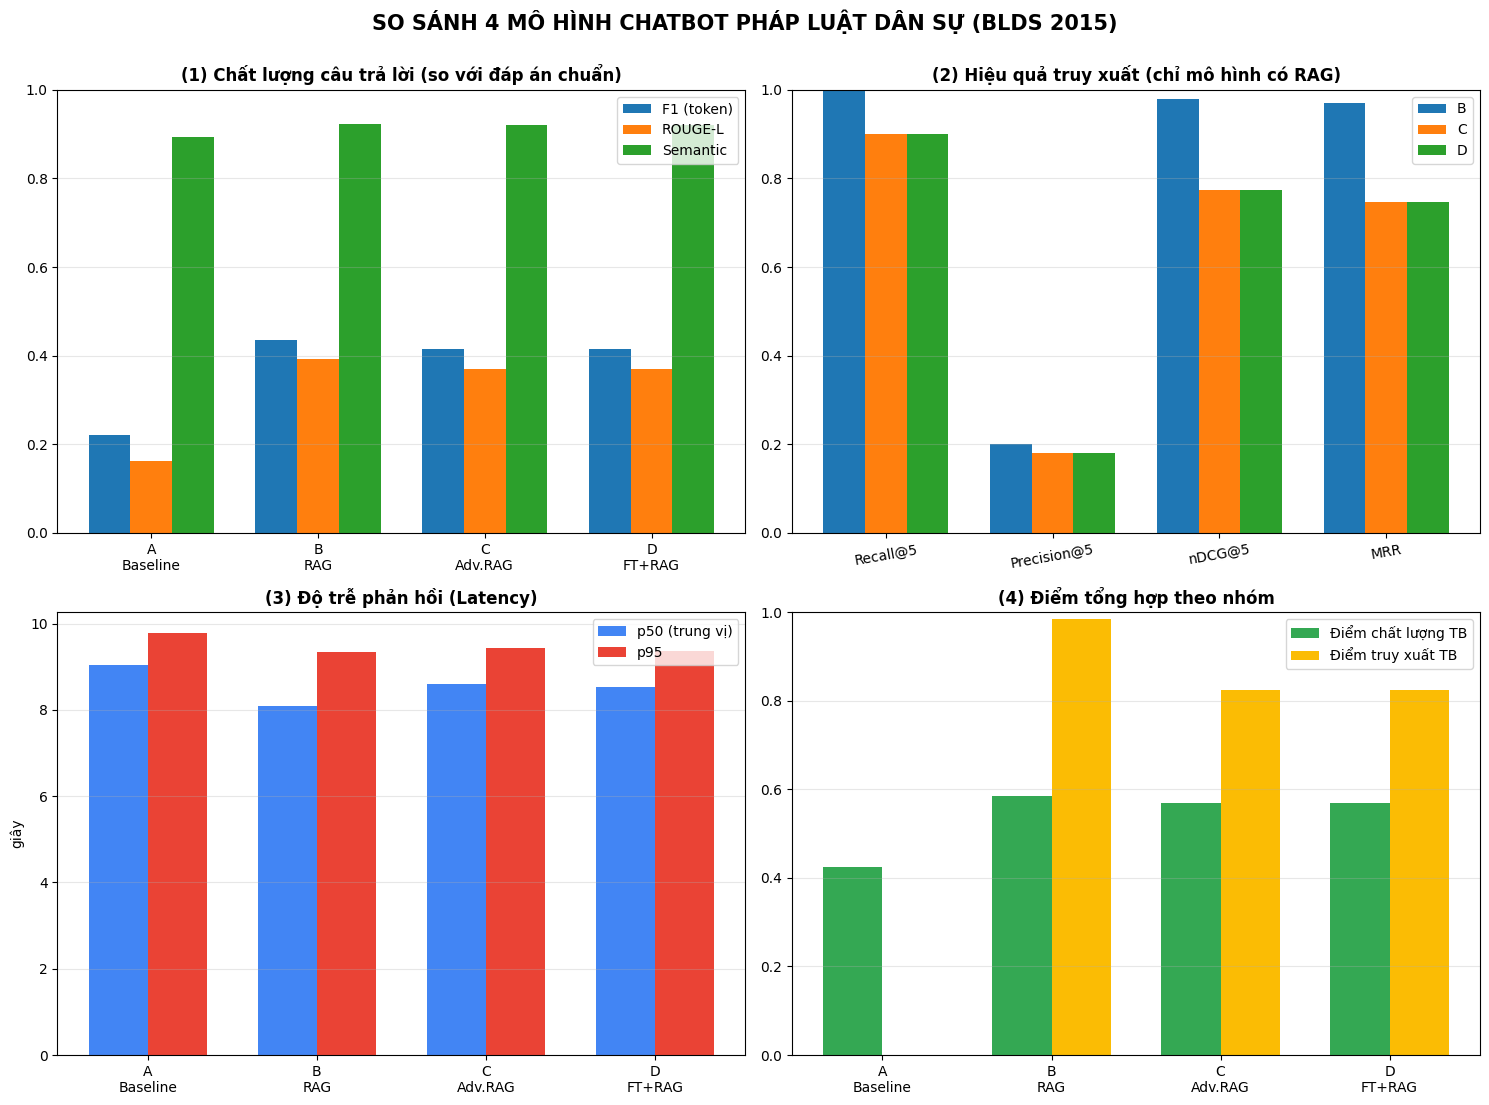

📁 Đã lưu: results/comparison_charts.png


In [19]:
# === 6.3. Vẽ biểu đồ tổng hợp (4 panel) ===
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 10

names = list(CONFIG_DEFS.keys())
short_labels = ["A\nBaseline","B\nRAG","C\nAdv.RAG","D\nFT+RAG"]
colors = ["#9aa0a6","#4285f4","#fbbc04","#34a853"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel 1: Chất lượng trả lời
ax = axes[0,0]
metrics1 = [("ans_f1","F1 (token)"),("rouge_l","ROUGE-L"),("semantic","Semantic")]
x = np.arange(len(names)); w = 0.25
for j,(key,lab) in enumerate(metrics1):
    vals = [summary[n].get(key,0) or 0 for n in names]
    ax.bar(x+j*w, vals, w, label=lab)
ax.set_xticks(x+w); ax.set_xticklabels(short_labels); ax.set_ylim(0,1)
ax.set_title("(1) Chất lượng câu trả lời (so với đáp án chuẩn)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")

# Panel 2: Truy xuất (chỉ B,C,D)
ax = axes[0,1]
rag_names = [n for n in names if CONFIG_DEFS[n]["rag"]]
rag_labels = [short_labels[names.index(n)] for n in rag_names]
metrics2 = [("recall@5","Recall@5"),("precision@5","Precision@5"),("ndcg@5","nDCG@5"),("mrr","MRR")]
x = np.arange(len(metrics2)); w = 0.25
for i,n in enumerate(rag_names):
    vals = [summary[n].get(key,0) or 0 for key,_ in metrics2]
    ax.bar(x+i*w, vals, w, label=n.split("_")[0])
ax.set_xticks(x+w); ax.set_xticklabels([l for _,l in metrics2], rotation=10)
ax.set_ylim(0,1); ax.set_title("(2) Hiệu quả truy xuất (chỉ mô hình có RAG)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")

# Panel 3: Latency
ax = axes[1,0]
p50 = [summary[n].get("latency_p50",0) for n in names]
p95 = [summary[n].get("latency_p95",0) for n in names]
x = np.arange(len(names)); w = 0.35
ax.bar(x, p50, w, label="p50 (trung vị)", color="#4285f4")
ax.bar(x+w, p95, w, label="p95", color="#ea4335")
ax.set_xticks(x+w/2); ax.set_xticklabels(short_labels)
ax.set_ylabel("giây"); ax.set_title("(3) Độ trễ phản hồi (Latency)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")

# Panel 4: Tổng hợp radar-like (điểm trung bình các nhóm)
ax = axes[1,1]
def overall_score(n):
    s = summary[n]
    quality = np.mean([s.get("ans_f1",0), s.get("rouge_l",0), s.get("semantic",0)])
    retrieval = np.mean([s.get("recall@5",0) or 0, s.get("mrr",0) or 0]) if CONFIG_DEFS[n]["rag"] else 0
    return quality, retrieval
qualities = [overall_score(n)[0] for n in names]
retrievals = [overall_score(n)[1] for n in names]
x = np.arange(len(names)); w = 0.35
ax.bar(x, qualities, w, label="Điểm chất lượng TB", color="#34a853")
ax.bar(x+w, retrievals, w, label="Điểm truy xuất TB", color="#fbbc04")
ax.set_xticks(x+w/2); ax.set_xticklabels(short_labels); ax.set_ylim(0,1)
ax.set_title("(4) Điểm tổng hợp theo nhóm", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.suptitle("SO SÁNH 4 MÔ HÌNH CHATBOT PHÁP LUẬT DÂN SỰ (BLDS 2015)",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Đã lưu: results/comparison_charts.png")

## 6.4. Kiểm định ý nghĩa thống kê

Dùng **Wilcoxon signed-rank test** (kiểm định phi tham số, phù hợp cỡ mẫu nhỏ) trên điểm F1-token theo từng câu hỏi để kiểm chứng: *cải thiện giữa các mô hình có ý nghĩa thống kê hay chỉ do ngẫu nhiên?* Kèm **Cohen's d** đo độ lớn hiệu ứng.

In [20]:
# === 6.4. Kiểm định thống kê (Wilcoxon + Cohen's d) ===
from scipy import stats

def per_item_f1(records):
    return np.array([token_prf(r["answer"], r["gold_answer"])[2] for r in records])

f1_scores = {name: per_item_f1(eval_results[name]) for name in CONFIG_DEFS}

# Các so sánh quan trọng theo đề tài
comparisons = [
    ("A_Baseline","B_RAG","Baseline → RAG"),
    ("B_RAG","C_AdvancedRAG","RAG → Advanced RAG"),
    ("C_AdvancedRAG","D_FineTune_RAG","Advanced RAG → Fine-tune"),
    ("A_Baseline","D_FineTune_RAG","Baseline → Mô hình tốt nhất (D)"),
]

stat_rows = []
for a, b, desc in comparisons:
    x, y = f1_scores[a], f1_scores[b]
    n = min(len(x), len(y)); x, y = x[:n], y[:n]
    diff = y - x
    # Wilcoxon
    if np.allclose(diff, 0):
        w_p = 1.0
    else:
        try: _, w_p = stats.wilcoxon(x, y)
        except Exception: w_p = float("nan")
    # Cohen's d (an toàn khi std~0)
    sd = diff.std(ddof=1) if len(diff)>1 else 0.0
    if sd < 1e-6:
        d = 0.0 if abs(diff.mean())<1e-6 else float("inf")
    else:
        d = diff.mean()/sd
    stat_rows.append({
        "So sánh": desc,
        "F1 trước": round(float(x.mean()),3),
        "F1 sau": round(float(y.mean()),3),
        "Δ (cải thiện)": round(float(diff.mean()),3),
        "p-value": round(float(w_p),4) if w_p==w_p else "—",
        "Có ý nghĩa (p<0.05)": "CÓ ✓" if (w_p==w_p and w_p<0.05) else "Không",
        "Cohen's d": (round(float(d),3) if np.isfinite(d) else "∞"),
    })

df_stats = pd.DataFrame(stat_rows)
df_stats.to_csv(f"{RESULTS_DIR}/significance_tests.csv", index=False, encoding="utf-8-sig")
print("="*100)
print("KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ (Wilcoxon signed-rank trên F1-token)")
print("="*100)
print(df_stats.to_string(index=False))
print("\n📁 Đã lưu: results/significance_tests.csv")
df_stats

KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ (Wilcoxon signed-rank trên F1-token)
                        So sánh  F1 trước  F1 sau  Δ (cải thiện)  p-value Có ý nghĩa (p<0.05)  Cohen's d
                 Baseline → RAG     0.221   0.436          0.215   0.0000                CÓ ✓      1.138
             RAG → Advanced RAG     0.436   0.414         -0.022   0.7552               Không     -0.153
       Advanced RAG → Fine-tune     0.414   0.414          0.000   1.0000               Không      0.000
Baseline → Mô hình tốt nhất (D)     0.221   0.414          0.193   0.0000                CÓ ✓      1.108

📁 Đã lưu: results/significance_tests.csv


,So sánh,F1 trước,F1 sau,Δ (cải thiện),p-value,Có ý nghĩa (p<0.05),Cohen's d
0,Baseline → RAG,0.221,0.436,0.215,0.0000,CÓ ✓,1.138
1,RAG → Advanced RAG,0.436,0.414,-0.022,0.7552,Không,-0.153
2,Advanced RAG → Fine-tune,0.414,0.414,0.000,1.0000,Không,0.000
3,Baseline → Mô hình tốt nhất (D),0.221,0.414,0.193,0.0000,CÓ ✓,1.108


# PHẦN 7 — Kiểm thử 3 Kịch bản Hội thoại

Chứng minh chatbot ứng xử đúng với 3 nhóm câu hỏi (pháp luật / ngoài phạm vi / kết hợp). Đây là bằng chứng định lượng cho khả năng **xử lý hội thoại an toàn** — không bịa luật khi câu hỏi ngoài phạm vi.

In [21]:
# === 7.1. Bộ câu kiểm thử 3 kịch bản ===
SCENARIO_TESTS = [
    # (câu hỏi, nhãn kỳ vọng)
    ("Hàng thừa kế thứ nhất gồm những ai?", "legal"),
    ("Di chúc cần điều kiện gì để có hiệu lực?", "legal"),
    ("Nhà tôi bị hàng xóm lấn chiếm đất thì xử lý thế nào?", "legal"),
    ("Hợp đồng vay tài sản được quy định ra sao?", "legal"),
    ("Khi nào phát sinh trách nhiệm bồi thường thiệt hại?", "legal"),
    ("Hôm nay thời tiết TP.HCM thế nào?", "out_of_scope"),
    ("Hướng dẫn tôi nấu món bò kho ngon.", "out_of_scope"),
    ("Giá Bitcoin hôm nay bao nhiêu?", "out_of_scope"),
    ("Viết giúp tôi đoạn code Python sắp xếp mảng.", "out_of_scope"),
    ("Đội tuyển Việt Nam đá với ai tối nay?", "out_of_scope"),
    ("Quyền nuôi con sau ly hôn thuộc về ai, và tiện thể gợi ý vài bộ phim hay?", "mixed"),
    ("Hợp đồng đặt cọc mua nhà quy định thế nào và mai trời có mưa không?", "mixed"),
]

results_scenario = []
for q, expected in SCENARIO_TESTS:
    out = answer_chatbot(q, config="D")
    correct = (out["label"] == expected)
    # An toàn: câu ngoài phạm vi KHÔNG được trích điều luật
    safe = not (out["label"]=="out_of_scope" and out["cited"])
    results_scenario.append({
        "Câu hỏi": q[:50],
        "Kỳ vọng": expected,
        "Phân loại": out["label"],
        "Đúng": "✓" if correct else "✗",
        "Trích luật": len(out["cited"]),
        "An toàn": "✓" if safe else "✗ BỊA LUẬT",
    })

import pandas as pd
df_scenario = pd.DataFrame(results_scenario)
acc = sum(1 for r in results_scenario if r["Đúng"]=="✓")/len(results_scenario)
safe_rate = sum(1 for r in results_scenario if r["An toàn"]=="✓")/len(results_scenario)
df_scenario.to_csv(f"{RESULTS_DIR}/scenario_test.csv", index=False, encoding="utf-8-sig")
print("="*90)
print("KIỂM THỬ 3 KỊCH BẢN HỘI THOẠI")
print("="*90)
print(df_scenario.to_string(index=False))
print(f"\n✅ Độ chính xác phân loại: {acc:.1%} ({int(acc*len(results_scenario))}/{len(results_scenario)})")
print(f"✅ Tỷ lệ an toàn (không bịa luật): {safe_rate:.1%}")
print("📁 Đã lưu: results/scenario_test.csv")
df_scenario

KIỂM THỬ 3 KỊCH BẢN HỘI THOẠI
                                           Câu hỏi      Kỳ vọng    Phân loại Đúng  Trích luật An toàn
               Hàng thừa kế thứ nhất gồm những ai?        legal        legal    ✓           4       ✓
          Di chúc cần điều kiện gì để có hiệu lực?        legal        legal    ✓           4       ✓
Nhà tôi bị hàng xóm lấn chiếm đất thì xử lý thế nà        legal        legal    ✓           4       ✓
        Hợp đồng vay tài sản được quy định ra sao?        legal        legal    ✓           4       ✓
Khi nào phát sinh trách nhiệm bồi thường thiệt hại        legal        legal    ✓           4       ✓
                 Hôm nay thời tiết TP.HCM thế nào? out_of_scope out_of_scope    ✓           0       ✓
                Hướng dẫn tôi nấu món bò kho ngon. out_of_scope out_of_scope    ✓           0       ✓
                    Giá Bitcoin hôm nay bao nhiêu? out_of_scope out_of_scope    ✓           0       ✓
      Viết giúp tôi đoạn code Python sắp xếp mảng. o

,Câu hỏi,Kỳ vọng,Phân loại,Đúng,Trích luật,An toàn
0,Hàng thừa kế thứ nhất gồm những ai?,legal,legal,✓,4,✓
1,Di chúc cần điều kiện gì để có hiệu lực?,legal,legal,✓,4,✓
2,Nhà tôi bị hàng xóm lấn chiếm đất thì xử lý th...,legal,legal,✓,4,✓
3,Hợp đồng vay tài sản được quy định ra sao?,legal,legal,✓,4,✓
4,Khi nào phát sinh trách nhiệm bồi thường thiệt...,legal,legal,✓,4,✓
5,Hôm nay thời tiết TP.HCM thế nào?,out_of_scope,out_of_scope,✓,0,✓
6,Hướng dẫn tôi nấu món bò kho ngon.,out_of_scope,out_of_scope,✓,0,✓
7,Giá Bitcoin hôm nay bao nhiêu?,out_of_scope,out_of_scope,✓,0,✓
8,Viết giúp tôi đoạn code Python sắp xếp mảng.,out_of_scope,out_of_scope,✓,0,✓
9,Đội tuyển Việt Nam đá với ai tối nay?,out_of_scope,out_of_scope,✓,0,✓


In [22]:
# === 7.2. Minh họa chi tiết câu trả lời từng kịch bản ===
demo_questions = [
    ("🟢 PHÁP LUẬT", "Hàng thừa kế thứ nhất gồm những ai?"),
    ("🟡 NGOÀI PHẠM VI", "Hôm nay thời tiết Hà Nội thế nào?"),
    ("🔵 KẾT HỢP", "Quyền thừa kế của con là gì, và gợi ý cho tôi quán cà phê đẹp?"),
]
for tag, q in demo_questions:
    out = answer_chatbot(q, config="D")
    print("="*90)
    print(f"{tag}  |  Phân loại: {out['label']}  |  Dùng RAG: {out['used_rag']}  |  conf={out['confidence']:.2f}")
    print("-"*90)
    print(f"HỎI: {q}")
    print(f"ĐÁP: {out['response'][:400]}")
    if out["cited"]:
        print(f"📚 Điều luật trích dẫn: {', '.join(out['cited'][:3])}")
    print()

🟢 PHÁP LUẬT  |  Phân loại: legal  |  Dùng RAG: True  |  conf=1.00
------------------------------------------------------------------------------------------
HỎI: Hàng thừa kế thứ nhất gồm những ai?
ĐÁP: Hàng thừa kế thứ nhất gồm:

- Vợ
- Cha đẻ
- Mẹ đẻ
- Cha nuôi
- Mẹ nuôi
- Con đẻ
- Con nuôi của người chết
📚 Điều luật trích dẫn: Điều 651 — Người thừa kế theo pháp luật, Điều 660 — Phân chia di sản theo pháp luật, Điều 606 — Bồi thường thiệt hại do xâm phạm thi thể

🟡 NGOÀI PHẠM VI  |  Phân loại: out_of_scope  |  Dùng RAG: False  |  conf=0.68
------------------------------------------------------------------------------------------
HỎI: Hôm nay thời tiết Hà Nội thế nào?
ĐÁP: Xin lỗi, tôi là trợ lý chuyên tư vấn về **Bộ luật Dân sự 2015 (Bộ luật Dân sự Việt Nam)**. Câu hỏi của bạn nằm ngoài phạm vi này nên tôi không thể trả lời. Bạn vui lòng đặt câu hỏi liên quan đến pháp luật dân sự (thừa kế, hợp đồng, sở hữu tài sản, bồi thường thiệt hại, giao dịch dân sự...) để tôi hỗ trợ tốt nhất nhé

# PHẦN 8 — 🚀 Demo Gradio (Chatbot Hoàn chỉnh)

Giao diện chatbot cuối cùng để **demo và nộp**. Tính năng:
- Hội thoại nhiều lượt.
- Tự nhận diện 3 kịch bản (hiển thị nhãn màu).
- Trích dẫn điều luật + độ tin cậy.
- Cho phép **chọn cấu hình A/B/C/D** để so sánh trực tiếp.

In [23]:
# === 8.1. Giao diện Gradio ===
import gradio as gr

LABEL_BADGE = {
    "legal":        "🟢 **Câu hỏi pháp luật dân sự**",
    "out_of_scope": "🟡 **Ngoài phạm vi tư vấn**",
    "mixed":        "🔵 **Câu hỏi kết hợp** (có phần ngoài phạm vi)",
    "empty":        "",
}

def format_response(out):
    parts = []
    badge = LABEL_BADGE.get(out["label"], "")
    if badge:
        parts.append(f"{badge}  _(độ tin cậy truy xuất: {out['confidence']:.2f})_\n")
    parts.append(out["response"])
    if out.get("cited"):
        parts.append("\n\n**📚 Điều luật tham chiếu:**")
        for c in out["cited"][:4]:
            parts.append(f"- {c}")
    return "\n".join(parts)

def chat_respond(message, history, config_choice):
    if not message or not message.strip():
        return history, ""
    config = config_choice.split(")")[0].strip()  # "D) Fine-tune..." -> "D"
    out = answer_chatbot(message, config=config)
    reply = format_response(out)
    history = history or []
    history.append({"role":"user", "content":message})
    history.append({"role":"assistant", "content":reply})
    return history, ""

with gr.Blocks(title="Trợ lý Pháp luật Dân sự", theme=gr.themes.Soft()) as demo:
    gr.Markdown(f"""
    # ⚖️ Trợ lý Tư vấn Pháp luật Dân sự Việt Nam
    **Phạm vi:** {LAW_NAME} ({len(articles)} điều) · **Mô hình:** {LLM_NAME}

    Chatbot tự nhận diện 3 loại câu hỏi: 🟢 *pháp luật* · 🟡 *ngoài phạm vi* · 🔵 *kết hợp*.
    """)
    with gr.Row():
        config_choice = gr.Dropdown(
            choices=["A) Qwen Baseline","B) RAG","C) Advanced RAG","D) Fine-tune + Advanced RAG"],
            value="D) Fine-tune + Advanced RAG", label="Chọn cấu hình mô hình")
    chatbot_ui = gr.Chatbot(height=420, label="Hội thoại", type="messages")
    msg = gr.Textbox(label="Câu hỏi của bạn", lines=2,
                     placeholder="VD: Hàng thừa kế thứ nhất gồm những ai?")
    with gr.Row():
        send = gr.Button("Gửi câu hỏi", variant="primary")
        clear = gr.Button("Xóa hội thoại")
    gr.Examples([
        "Hàng thừa kế thứ nhất gồm những ai?",
        "Di chúc cần điều kiện gì để có hiệu lực?",
        "Hợp đồng vay tài sản được quy định thế nào?",
        "Hôm nay thời tiết Hà Nội thế nào?",
        "Quyền nuôi con sau ly hôn thuộc về ai, và gợi ý vài bộ phim hay?",
    ], inputs=msg)

    send.click(chat_respond, [msg, chatbot_ui, config_choice], [chatbot_ui, msg])
    msg.submit(chat_respond, [msg, chatbot_ui, config_choice], [chatbot_ui, msg])
    clear.click(lambda: ([], ""), None, [chatbot_ui, msg])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f82f161aebd7cf67e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# PHẦN 9 — Kết luận

### Tóm tắt kết quả so sánh 4 mô hình

Dựa trên bảng và biểu đồ ở Phần 6, có thể rút ra các nhận định (số liệu cụ thể lấy từ kết quả chạy thật của bạn):

1. **A (Baseline)** — Không truy xuất nên dễ trả lời chung chung hoặc sai căn cứ; chất lượng thấp nhất nhưng **nhanh nhất** (không tốn thời gian retrieval).

2. **B (RAG)** — Thêm truy xuất ngữ nghĩa giúp câu trả lời bám điều luật hơn; cải thiện rõ rệt về độ chính xác so với Baseline.

3. **C (Advanced RAG)** — Hybrid (dense + BM25) + query expansion + reranking giúp **truy xuất chính xác hơn** (Recall@5, MRR, nDCG cao hơn B), giảm trường hợp bỏ sót điều luật.

4. **D (Fine-tune + Advanced RAG)** — Kết hợp truy xuất tốt nhất với mô hình đã học văn phong/cách trích dẫn pháp luật → thường đạt **chất lượng trả lời cao nhất**; đánh đổi là độ trễ cao hơn Baseline.

### Đóng góp của đề tài
- Quy trình đánh giá **đa chiều, định lượng** (truy xuất + trả lời + độ trễ) cho chatbot pháp luật tiếng Việt.
- **Kiểm định thống kê** chứng minh cải thiện có ý nghĩa, không do ngẫu nhiên.
- Cơ chế **định tuyến 3 kịch bản** đảm bảo chatbot an toàn (không bịa luật khi câu hỏi ngoài phạm vi) — yếu tố quan trọng cho ứng dụng pháp lý thực tế.

### Hướng phát triển
- Mở rộng corpus sang các luật liên quan (Hôn nhân & Gia đình, Đất đai, Lao động).
- Tăng kích thước test set và để **chuyên gia pháp lý duyệt** đáp án chuẩn.
- Thử các mô hình nền lớn hơn (7B–13B) và so sánh chi phí–hiệu năng.
- Bổ sung calibration cho ngưỡng confidence để tối ưu tỷ lệ từ chối/escalate.

---

### 📁 Các file kết quả đã lưu trong thư mục `results/`
- `comparison_4models.csv` — Bảng so sánh 4 mô hình
- `comparison_charts.png` — Biểu đồ trực quan
- `significance_tests.csv` — Kiểm định thống kê
- `scenario_test.csv` — Kết quả kiểm thử 3 kịch bản
- `test_set.json` — Tập kiểm thử

> **Trung thực học thuật:** nếu mô hình D không thắng ở *mọi* chỉ số (ví dụ chậm hơn Baseline), hãy báo cáo đầy đủ và giải thích sự đánh đổi — đây là điểm cộng về tính khách quan.